# Implementing Reinforcement Learnig Algorithms in Games

### Setup

In [50]:
import ipywidgets as widgets
import matplotlib.pyplot as plt
import tqdm
import random
from collections import deque

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

import stable_retro
import gymnasium as gym

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"

print(f"Using {device} device")

Using cuda device


### Set up Envionrment and Wrappers

In [ ]:
class AirStrikerActionWrapper(gym.ActionWrapper):
    # This class will simplify the action space available to the agent into a discrete space that is mapped to the button inputs on a Genesis controller.
    # Normally there are many different possible action inputs that make the state-action space much more complex

    def __init__(self, env):
        super().__init__(env)

        self._actions = [
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # 0: Do nothing
            [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # 1: LEFT
            [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], # 2: RIGHT
            [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0], # 3: UP
            [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0], # 4: DOWN
            [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], # 5: SHOOT
            [1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0], # 6: SHOOT + LEFT
            [1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0], # 7: SHOOT + RIGHT
        ]
        self.action_space = gym.spaces.Discrete(len(self._actions))

    def action(self, action):
        return np.array(self._actions[action].copy(), dtype=np.int8)

In [ ]:
class ClipReward(gym.RewardWrapper):
    # This class will clip the rewards to within a range of [-1, 1] instead of having potentially very large values
    
    def __init__(self, env):
        super().__init__(env)

    def reward(self, reward):
        # np.sign returns -1 for negative, 0 for zero, 1 for positive
        return np.sign(reward)

In [49]:
# Use the built-in wrappers for observation and frame stacking provided by gymnasium

from gymnasium.wrappers import GrayscaleObservation, ResizeObservation, FrameStackObservation

def create_airstriker_env(compressed_square_image_size, num_stacked_frames):
    # Create the base environment
    env = stable_retro.make(game="Airstriker-Genesis-v0")
    # use "python -m stable_retro.examples.interactive --game Airstriker-Genesis-v0" to test the game manually
    
    # using our custom action wrapper to simplify controller inputs
    env = AirStrikerActionWrapper(env)
    
    # using pre-made observation wrappers to simplify the input to the agent
    # make the image grayscale to remove high dimensionality of using colors
    env = GrayscaleObservation(env, keep_dim=False)
    # Compress the image from 224 x 320 to 84 x 84 
    env = ResizeObservation(env, shape=compressed_square_image_size)
    
    # using custom reward clipping wrapper
    env = ClipReward(env)
    
    # using frame stacking to capture velocity of player ship and enemy objects
    # using 4 frames
    env = FrameStackObservation(env, num_stack=num_stacked_frames)
    
    return env

### Setting up DQN Helper Functions and Base Classes

In [ ]:
class DeepQNet(nn.Module):
    # Need to use a CNN
    def __init__(self, input_dim, num_hidden_layer, dim_hidden_layer, output_dim):
        super(DeepQNet, self).__init__()

        self.input_dim = input_dim
        self.num_hidden_layer = num_hidden_layer
        self.dim_hidden_layer = dim_hidden_layer
        self.output_dim = output_dim

        # Creating the network
        
        # define the input linear layer here
        self.input_layer = nn.Linear(self.input_dim, self.dim_hidden_layer)

        # define the activation function after the input layer (use the ReLU as the activation function)
        self.input_layer_activation = nn.ReLU()

        # store hidden layers and their activation functions in pairs as tuples, inside a ModuleList
        # last one will be slightly different because it must return output 1-dimensional output

        self.hidden_layers = nn.ModuleList()

        for _ in range(self.num_hidden_layer):
          new_hidden_layer_group = nn.Sequential(nn.Linear(self.dim_hidden_layer, self.dim_hidden_layer), nn.ReLU())
          self.hidden_layers.append(new_hidden_layer_group)

        # define the output layer here
        self.output_layer = nn.Linear(self.dim_hidden_layer, self.output_dim)
    
    # forward propogation
    def forward(self, x):
      # forward x through the input layer
      x = self.input_layer(x)

      # apply activation
      x = self.input_layer_activation(x)

      for hidden_layer in self.hidden_layers:
        x = hidden_layer(x)

      # forward x throught the output layer
      y = self.output_layer(x)

      return y

In [ ]:
class DQN_CNN(nn.Module):
    def __init__(self, batch_size, input_channels=4, num_actions=8):
        super(DQN_CNN, self).__init__()

        self.batch_size = batch_size
        
        # input dimensions: (batch_size, 4, 84, 84)
        self.features = nn.Sequential(
            nn.Conv2d(input_channels, self.batch_size, kernel_size=8, stride=4),
            nn.ReLU(),
            nn.Conv2d(self.batch_size, 64, kernel_size=4, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, stride=1),
            nn.ReLU()
        )
        
        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7, 512), 
            nn.ReLU(),
            nn.Linear(512, num_actions) # Final output: (Batch, 8)
        )

    def forward(self, x):
        # input shape: (batch_size, 4, 84, 84)
        
        # Pass through convolutional layers
        x = self.features(x)
        
        # flatten the 3D tensor to 1D vector (keeping the batch dimension)
        x = x.view(x.size(0), -1) 
        
        # pass through the linear decision head at the end
        # output shape: (batch_size, 8)
        x = self.fc(x)
        
        return x

In [52]:
class ReplayBuffer(object):
    # This class will create a replay buffer that the learning neural network to sample from in order to train
    # it maintains a list of transitions in the form of 5-dimensional tuples like so: (state, action, next_state, reward, done)

    def __init__(self, batch_size, total_size):
        self.batch_size = batch_size
        self.total_size = total_size

        self.curr_len = 0

        self.buffer = deque([])

    def fetch_sample(self):
        self.curr_len -= self.batch_size
        
        return np.random.choice(self.buffer, size=self.batch_size, replace=False)

    # experience should be a list of tuples with dimension 5 like so: (state, action, next_state, reward, done)
    # assume len(experience) = batch_size
    def add_experience(self, experience):
        if not len(experience) == self.batch_size:
            raise Exception(f"Experience added to replay buffer (len={len(experience)}) should equal batch_size (len={self.batch_size})")
        
        if self.curr_len == self.total_size:
            self.buffer.popleft(self.batch_size)
            self.curr_len -= len(experience)
        
        if self.curr_len <= self.total_size - self.batch_size:
            for transition_tuple in experience:
                self.buffer.append(transition_tuple)
            self.curr_len += len(experience)
        
        return

In [ ]:
# Code skeleton taken from Assginment 7 on DQNs

class NeuralNetTrainer(object):
    def __init__(self, dataset, network_model, params, debug_flag):
        """ To train a Neural Network, we need:
                - The training set
                - The Neural Network model
                - A Loss function
                - An Optimizer
                - other parameters
            Thanks to Pytorch, we can use the built-in Loss function and the Optimizer.

            Args:
                dataset (list): a list contains all training data
                network_model (nn.Module): a Pytorch defined neural network
                params (dict): a dictionary stores the training parameters
        """
        # Dataset
        self.dataset = dataset

        # We can specify the device to train the model: cpu or GPU
        self.device = torch.device(params['device'])
        # Send the model to the device
        self.model = network_model.to(self.device)

        """ CODE HERE:
                - Create the ADAM optimizer
                - MSE loss
        """
        # Define the Adam optimizer with specified leaarning rate and weight decay in "params"
        self.optimizer = torch.optim.Adam(self.model.parameters(), lr=params["learning_rate"])

        self.loss = nn.MSELoss()

        # Save the training parameters
        self.params = params

        self.debug_flag = debug_flag

    # We use a simple Mean Square Error (MSE) loss.
    def mse_loss(self, dataset):
      sum = 0
      for (y_1, y_2) in dataset:
        sum = sum + pow((y_1 - y_2), 2)

      return sum / len(dataset)

    def sample_mini_batch(self, dataset, batch_size):
        """ Function is used to sample a subset of the dataset to train the model.
            We usually call it "mini-batch" data in machine learning, which is widely
            used in stochastic gradient descend.

            Args:
                dataset (list):  a list contains all training data
                batch_size (int): size of the sampled training data.

            Returns:
                input_tensor (torch.tensor): A tensor variable with size |B| x |D_x|, where B = batch_size, and D_x is
                                             the dimension of x in one sampled data.
                output_tensor (torch.tensor): A tensor variable with size |B| x |D_y|, where B = batch_size, and D_y is
                                             the dimension of y in one sampled data.
        """
        # We should always shuffle the whole dataset before sampling
        np.random.shuffle(dataset)

        """ CODE HERE:
                - Sample a batch of training data
        """
        # Sample a batch data from the original dataset

        self.dataset_sample = dataset[0:batch_size]

        """ CODE HERE:
                - Split the data into x list and y list
        """
        # Split the x and y in the sampled data

        input_data = []
        output_data = []

        for (x, y) in self.dataset_sample:
          input_data.append(x)
          output_data.append(y)

        # Convert the input and output into tensor.
        input_tensor = torch.tensor(input_data, dtype=torch.float32).to(self.device).view(-1, 1)
        output_tensor = torch.tensor(output_data, dtype=torch.float32).to(self.device).view(-1, 1)

        return input_tensor, output_tensor

    def run(self):
        """ Function is used to run the training
        """
        if self.debug_flag:
          print("Entering run function")

        # Define the number of epochs to train the model
        ep_bar = tqdm.trange(self.params['epoch_num'], desc="epoch bar")

        # Save the training loss for plotting.
        # loss = torch.tensor([0])
        training_loss = []

        # Loop for every training epoch
        for ep in ep_bar:
            # For every epoch, we update the model with a fixed number (i.e., iteration_num in params)
            # of sampled batch data.
            for it in range(self.params['iteration_num']):
                # Sample a batch data
                x_tensor, gt_y_tensor = self.sample_mini_batch(self.dataset, self.params['batch_size'])

                """ CODE HERE:
                        - Perform a forward propagation
                """
                # Forward propagation
                output = self.model.forward(x_tensor)

                """ CODE HERE:
                        - Compute the loss after the forward propagation
                """
                # Compute the MSE loss value

                '''
                training_compare_data = []

                for index in range(len(output)):
                  actual = output[index]
                  target = gt_y_tensor[index]
                  training_compare_data.append((actual, target))

                loss = self.mse_loss(training_compare_data)
                '''
                loss = self.loss(output, gt_y_tensor)

                # Save the loss for plotting
                training_loss.append(loss.item())

                """ CODE HERE:
                        - Complete the backpropagation
                """
                # Perform one step back propagation
                self.optimizer.zero_grad()
                loss.backward()
                self.optimizer.step()

            # Set the value to tqdm bar
            ep_bar.set_description(f"Loss = {loss.item()}")

        # Plot the training loss
        plt.title(f"MSE loss curve with batch size={self.params['batch_size']}, learning rate={self.params['learning_rate']}")
        plt.plot(range(len(training_loss)), training_loss)
        plt.show()

        return x_tensor, output

    def plot_learned_function(self, dataset):
        """ Function to plot the learned non-linear function model (blue) v.s. the groud truth (red)

            Args:
                dataset (list): a list variable contains all evaluation (x, y) pairs.
        """
        x_tensor, y_tensor = self.sample_mini_batch(dataset, len(dataset))

        # compute the prediction for all data to evaluate
        with torch.no_grad():
            pred_y_tensor = self.model(x_tensor)

        # convert the data from tensor to list
        gt_x_list = x_tensor.cpu().numpy().tolist()
        gt_y_list = y_tensor.cpu().numpy().tolist()
        pred_y_list = pred_y_tensor.cpu().numpy().tolist()

        # plot the results
        fig, ax = plt.subplots()
        ax.set_title("Prediction (blue) v.s. Ground truth (red)")
        ax.scatter(gt_x_list, gt_y_list, label="gt", color="r")
        ax.scatter(gt_x_list, pred_y_list, label="pred", color="b")
        ax.legend()
        plt.show()

In [33]:
""" Function is used to create a dataset that contains "num" samples given a particular non-linear function.
    In this case, the non-linear function is f(x) = 1 + x ^ 2.
"""
def create_dataset(num, start_val, end_val):
    """ Function that generates a dataset

        Args:
            num (int): number of samples to generate
            start_val (float): the minimal value of x (included)
            end_val (float): the maximal value of x (included)

        Returns:
            dataset (list): a list consists of (x, y) pairs.
    """
    def nonlinear_function(val):
        """ CODE HERE: non-linear function: 1 + val ^ 2
        """
        return 1 + pow(val, 2)

    """ CODE HERE:
        - create "num" even values between start_val and end_val using numpy.linspace
        - create the dataset, which is a list of training tuples. e.g. (x, y)
    """
    even_values = np.linspace(start_val, end_val, num)

    dataset = [(x_val, nonlinear_function(x_val)) for x_val in even_values]

    return dataset

### Setting up DQN Agent

In [ ]:
# Write algorithm

### Testing Ground

Entering run function


Loss = 0.04284755513072014: 100%|██████████| 10/10 [00:12<00:00,  1.24s/it]


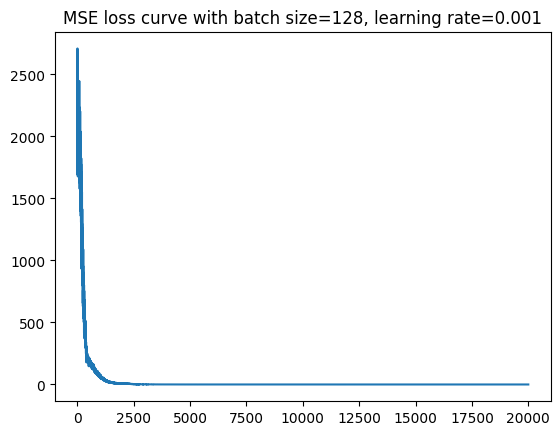

In [38]:
# Define hyperparameters

np.random.seed(1234)
random.seed(1234)
torch.manual_seed(1234)

train_params = {
    'epoch_num': 10,
    'iteration_num': 2000,
    'learning_rate': 1e-3,
    'weight_decay': 5e-4,
    'batch_size': 128,
    'device': "cpu"
}

my_network = DeepQNet(input_dim=1, num_hidden_layer=2, dim_hidden_layer=8, output_dim=1)

train_dataset = create_dataset(500, -10, 10)

my_trainer = NeuralNetTrainer(dataset=train_dataset, network_model=my_network, params=train_params, debug_flag=True)
x_vals, pred_vals = my_trainer.run()

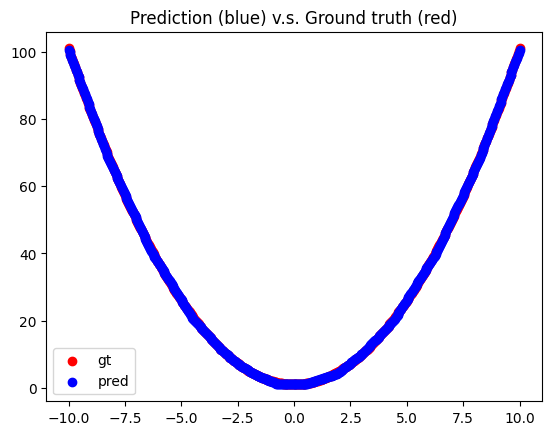

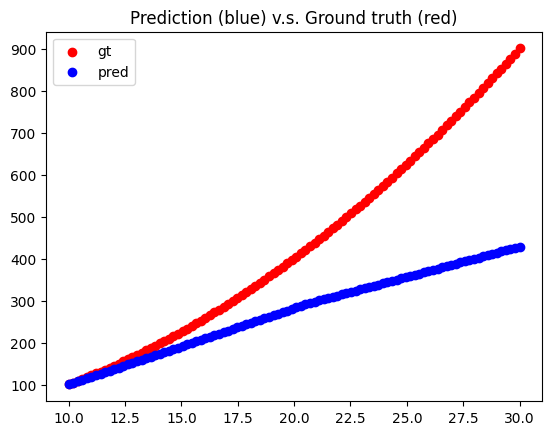

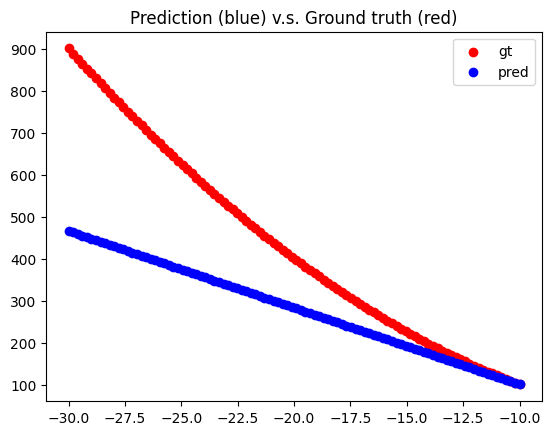

Parameter containing:
tensor([[-1.2417],
        [-0.5304],
        [-0.6718],
        [-0.4412],
        [-1.1307],
        [ 1.2873],
        [-1.0585],
        [-0.1196]], requires_grad=True)
Parameter containing:
tensor([-0.1689, -1.3626, -0.0805, -1.0476,  0.0095,  0.3564, -1.7680,  2.4703],
       requires_grad=True)
Parameter containing:
tensor([[-0.1530,  0.1108, -0.2139,  0.1635,  0.0423, -0.1676, -0.1734,  0.0622],
        [ 0.5944,  0.9990,  0.1896,  0.6400,  0.4438,  0.7771,  0.5947, -0.4874],
        [ 0.2944,  0.3212,  0.0676,  0.3784,  0.3001, -0.7660,  0.5738, -1.5607],
        [-0.8158, -0.3526, -0.8384, -0.5291, -0.9732,  0.5821, -0.0573, -2.5983],
        [ 0.2881,  0.6349,  0.0696,  0.4460,  0.0806,  0.5308,  0.5694, -2.6950],
        [-1.1754, -0.4181, -1.0430, -0.7879, -0.9859,  1.0902,  0.0275, -1.6116],
        [ 0.1256,  0.5119,  0.3925,  0.2876,  0.0428,  0.6302,  0.3273, -1.7730],
        [-0.3459,  0.3150,  0.1882, -0.1673, -0.2206,  0.0123,  0.2014, -0.2537

In [39]:
# training dataset to evaluate
train_dataset = create_dataset(500, -10, 10)

# test set 1: one test dataset contains samples with 10 < x < 30
upper_test_dataset = create_dataset(100, 10, 30)

# test set 2: one test dataset contains samples with -30 < x < -10
lower_test_dataset = create_dataset(100, -30, -10)

'''
print(x_vals)
print(pred_vals)
x_pred_vals = torch.stack((x_vals, pred_vals), dim=1)
'''

# Plot your results for all samples in the training set
my_trainer.plot_learned_function(train_dataset)

# Plot your results for all samples in test set 1
my_trainer.plot_learned_function(upper_test_dataset)

# Plot your results for all samples in test set 2
my_trainer.plot_learned_function(lower_test_dataset)

for param in my_network.parameters():
    print(param)

### Run the Agent